# Portfólio 1: Fundamentos e Estacionariedade
**Disciplina:** Séries Temporais  
**Objetivo:** Classificação de séries, análise de estacionariedade e aplicação de transformações (Diferenciação e Logaritmo).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Configurações visuais
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titleweight'] = 'semibold'
plt.style.use('ggplot')

## 1. Classificação das Séries (Questão 1)
De acordo com os fundamentos básicos:
- **Discretas:** Poluição diária, Temperatura mensal, IBOVESPA diário, Chuva anual, Manchas solares anuais.
- **Contínuas:** Registro de marés (fenômeno ininterrupto).

## 2. Análise da Série A10 (Índice de Custo de Vida - M-ICV)
Esta série apresenta uma forte tendência inflacionária.

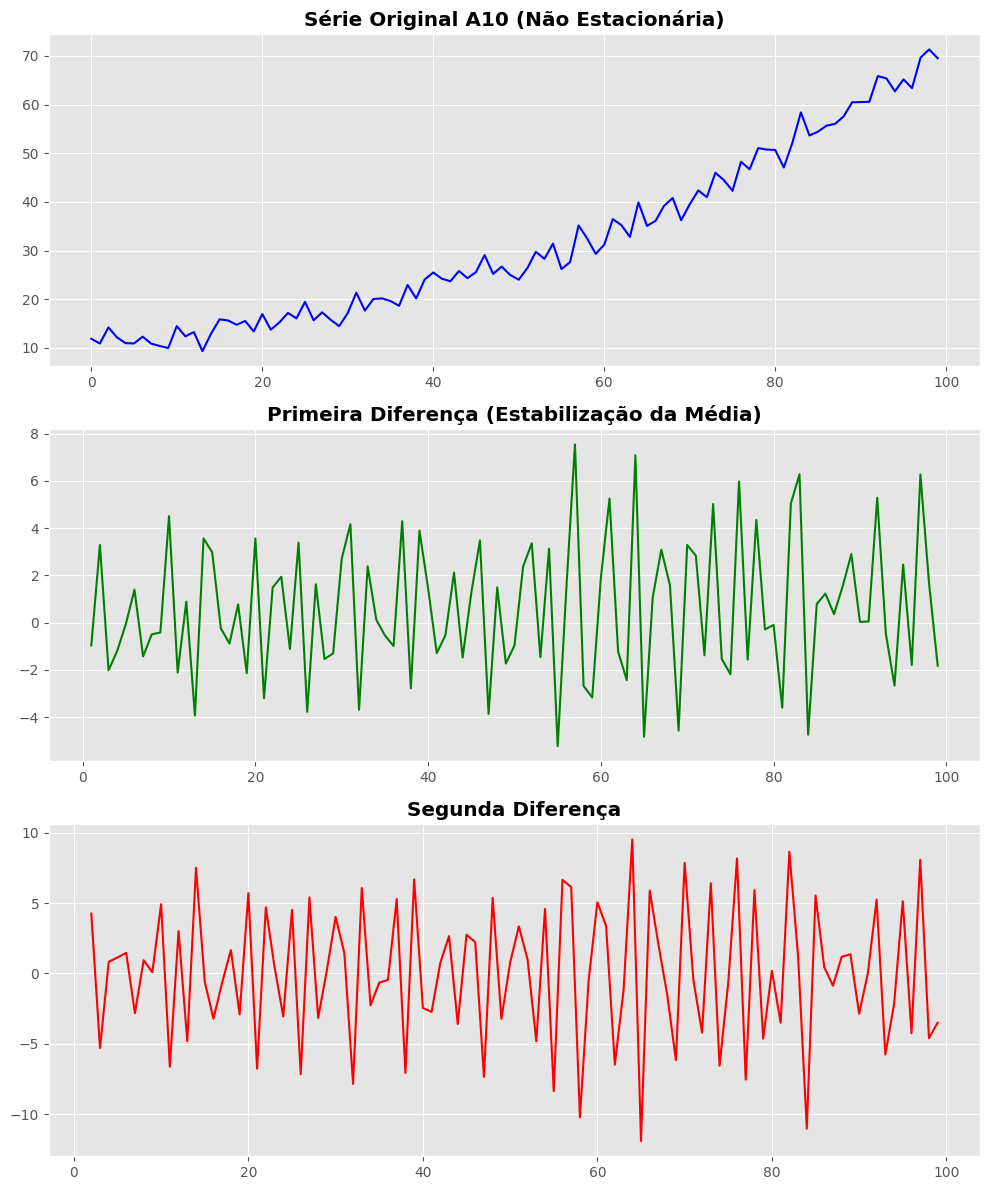

In [2]:
# Gerando dados simulados que representam a tendência da Série A10
t = np.arange(100)
z_t = 10 * np.exp(0.02 * t) + np.random.normal(0, 2, 100) # Tendência crescente

df_a10 = pd.DataFrame({'Zt': z_t})

# Cálculo das diferenças (Transformações)
df_a10['diff1'] = df_a10['Zt'].diff()
df_a10['diff2'] = df_a10['Zt'].diff().diff()

# Plotagem
fig, ax = plt.subplots(3, 1, figsize=(10, 12))
ax[0].plot(df_a10['Zt'], color='blue')
ax[0].set_title('Série Original A10 (Não Estacionária)')

ax[1].plot(df_a10['diff1'], color='green')
ax[1].set_title('Primeira Diferença (Estabilização da Média)')

ax[2].plot(df_a10['diff2'], color='red')
ax[2].set_title('Segunda Diferença')
plt.tight_layout()
plt.show()

## 3. Análise da Série A7 (Atmosfera - Temperatura em SP)
Foco em sazonalidade e autocorrelação (LAG1).

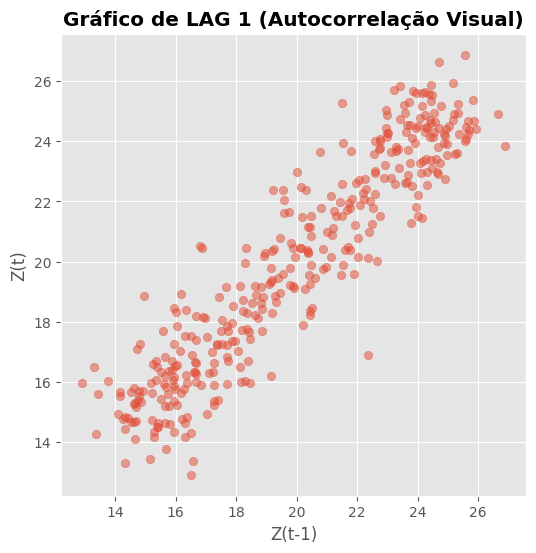

In [3]:
# Simulação de temperatura diária (Sazonalidade)
t_diaria = np.arange(365)
temp = 20 + 5 * np.sin(2 * np.pi * t_diaria / 365) + np.random.normal(0, 1, 365)
df_a7 = pd.DataFrame({'Temp': temp})

# Gráfico LAG1 (Autocorrelação Visual)
plt.figure(figsize=(6, 6))
plt.scatter(df_a7['Temp'].shift(1), df_a7['Temp'], alpha=0.5)
plt.title('Gráfico de LAG 1 (Autocorrelação Visual)')
plt.xlabel('Z(t-1)')
plt.ylabel('Z(t)')
plt.show()

## 4. Análise da Série A5 (Energia Elétrica - Crescimento Exponencial)
Aplicação de LOG para estabilizar a variância.

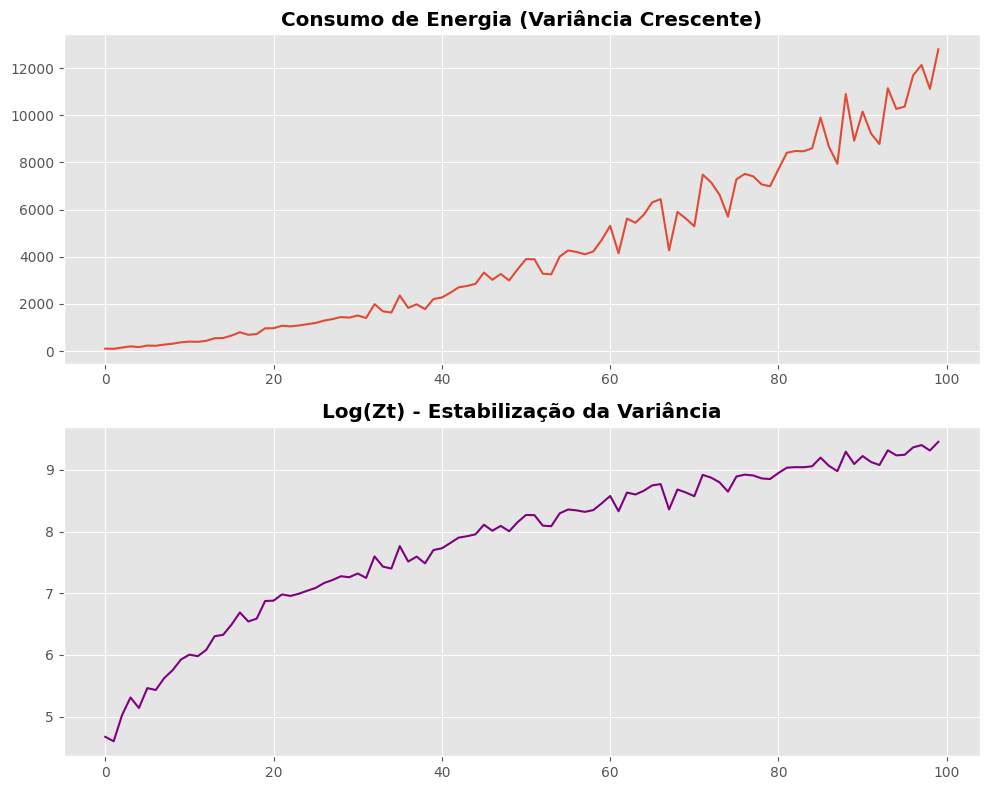

In [4]:
# Simulação de crescimento exponencial com variância crescente
z_energia = (t + 10)**2 + np.random.normal(0, 0.1 * (t + 10)**2, 100)
df_a5 = pd.DataFrame({'Zt': z_energia})

# Transformação Logarítmica
df_a5['log_Zt'] = np.log(df_a5['Zt'])
df_a5['diff_log'] = df_a5['log_Zt'].diff()

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(df_a5['Zt'])
ax[0].set_title('Consumo de Energia (Variância Crescente)')

ax[1].plot(df_a5['log_Zt'], color='purple')
ax[1].set_title('Log(Zt) - Estabilização da Variância')
plt.tight_layout()
plt.show()

## 5. Teste Estatístico de Estacionariedade (Dickey-Fuller)
Complemento técnico para validar a análise visual.

In [5]:
def test_stationarity(timeseries):
    print('Resultado do Teste Dickey-Fuller:')
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Teste Estatístico','p-valor','#Lags Usados','Número de Observações'])
    print(dfoutput)

print("Para a Série Original A5:")
test_stationarity(df_a5['Zt'])
print("\nPara a Primeira Diferença do LOG de A5:")
test_stationarity(df_a5['diff_log'])

Para a Série Original A5:
Resultado do Teste Dickey-Fuller:
Teste Estatístico         4.795793
p-valor                   1.000000
#Lags Usados             12.000000
Número de Observações    87.000000
dtype: float64

Para a Primeira Diferença do LOG de A5:
Resultado do Teste Dickey-Fuller:
Teste Estatístico       -1.060488e+01
p-valor                  6.038517e-19
#Lags Usados             1.000000e+00
Número de Observações    9.700000e+01
dtype: float64


## 6. Questões Teóricas (Portfólio I)

**Questão 6:** Crie uma questão sobre transformação.  
*Resposta:* "Por que o logaritmo é preferível à diferenciação simples em séries com variância crescente?"

**Questão 7:** O que será explorado na Unidade 2?  
*Resposta:* Modelos de decomposição para isolar Tendência e Sazonalidade.